# Exoplanet Transit Detection Prototype  
## A first notebook-based classification pipeline built around real Kepler light curves

In this notebook I am building a first prototype for an exoplanet transit detection project. My goal is not to pretend that I already have a production-grade scientific pipeline. My goal is to show a serious first version that already behaves like one. I want to work with real archive data, derive features from actual light curves, and train a first classifier that can distinguish planet-like transit signals from objects that the archive marks as false positives.

I deliberately chose a feature-based approach instead of jumping straight into a large deep learning model. For a first prototype, that would be the wrong trade-off. A notebook prototype should be understandable, reproducible, scientifically motivated, and realistic to present. This workflow gives me all of that. It also gives me enough structure to explain every part of the pipeline clearly: where the labels come from, how the light curves are prepared, how the signal search works, what the features mean, how the model is evaluated, and why the result is only the first version of a larger project.

The scientific idea behind the notebook is simple. A transiting exoplanet causes a small, repeated dip in the brightness of its host star. If I observe the brightness of a star over time, I can search that time series for periodic box-shaped decreases in flux. The standard tool for that search is the Box Least Squares periodogram, usually shortened to BLS. Once I recover the strongest transit-like signal from each light curve, I can summarize that signal using engineered features such as period, duration, depth, signal-to-noise, and several measures of light-curve scatter and symmetry. These features then become the input to a conventional machine learning classifier.

This notebook is written as a presentation-quality prototype. The explanations are intentionally detailed. I am assuming that the reader is willing to follow the full reasoning, but I am not assuming prior comfort with astronomy, time-series analysis, or transit detection.

## What this notebook is trying to prove

The purpose of this notebook is not to announce a discovery. The purpose is to demonstrate that the project already has a technically coherent backbone.

I want to show that I can do five things in one continuous workflow. I can retrieve a labeled set of Kepler Objects of Interest from NASA's archive. I can download the corresponding light curves with Lightkurve. I can detrend those light curves and search them for transit-like signals using BLS. I can convert each signal into a compact numerical representation. Finally, I can train and evaluate a first classifier on top of those engineered features.

That is enough for a strong prototype because it proves that the project is not only a theoretical idea. It already has data ingestion, preprocessing, scientific signal extraction, feature engineering, and machine learning evaluation inside one notebook.

## Environment note before running anything

This notebook uses the astronomy stack around Lightkurve, Astropy, and Jupyter. In practice, this setup is smoother on Python 3.11, 3.12, or 3.13 than on Python 3.14. If I see package-installation friction in a fresh environment, the cleanest move is to create a dedicated environment with Python 3.12 and run the notebook there.

I am keeping the installation cell inside the notebook because this project is meant to be demonstrated in Jupyter Lab. I want the setup to remain visible and reproducible.

In [1]:
# If this is a fresh environment, run this cell once.
# If the packages are already installed, I can leave it commented out.

# %pip install -q lightkurve pandas numpy matplotlib scikit-learn requests ipywidgets bokeh

In [2]:
from pathlib import Path
from io import StringIO
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import lightkurve as lk

from astropy.timeseries import BoxLeastSquares

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score
)

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

C:\Users\eduar\Documents\exoplanet-transit-finder\.venv\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


## Project configuration

I am exposing the main settings near the top of the notebook so that the workflow is easy to control during a demo.

The two most important choices are the number of targets per class and whether I want to rebuild the feature table from scratch. Rebuilding means downloading light curves again and rerunning the BLS search for every selected target. That is the scientifically honest path and the one I would use the first time. However, because this is a prototype notebook, I also want the option to cache intermediate results. This lets me rerun the notebook quickly during presentations without waiting for the full data-collection phase again.

I am also restricting the candidate periods to a range that is friendly for a first prototype. Very long periods are harder to recover quickly because they produce fewer observed transit events in a finite time baseline. For a first version I would rather work in a regime where the signal-search step is more stable and easier to demonstrate.

In [3]:
RANDOM_STATE = 42

N_CONFIRMED = 15
N_FALSE_POSITIVE = 15

MIN_PERIOD_DAYS = 0.75
MAX_PERIOD_DAYS = 20.0

PERIOD_GRID_SIZE = 2500
DURATION_GRID_HOURS = np.arange(1, 13, 1)  # 1h to 12h

REBUILD_FEATURES = True

DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
LIGHTKURVE_CACHE_DIR = DATA_DIR / "lightkurve_cache"

for folder in [DATA_DIR, RAW_DIR, PROCESSED_DIR, LIGHTKURVE_CACHE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

TARGET_CACHE_PATH = PROCESSED_DIR / "selected_targets.csv"
FEATURE_CACHE_PATH = PROCESSED_DIR / "transit_features.csv"
FAILURE_CACHE_PATH = PROCESSED_DIR / "failed_targets.csv"
CV_RESULTS_PATH = PROCESSED_DIR / "cross_validation_results.csv"
FEATURE_IMPORTANCE_PATH = PROCESSED_DIR / "feature_importance_random_forest.csv"

## Why the label source matters

A classifier is only as coherent as its labels. If the labels are vague, the model will also be vague. I therefore want the labels to come from a source that is already part of the professional astronomy workflow.

For this prototype I use the Kepler Objects of Interest cumulative table from the NASA Exoplanet Archive. The archive contains disposition labels such as `CONFIRMED` and `FALSE POSITIVE`. This is useful for a first prototype because it gives me a practical binary classification target. I am not inventing labels myself. I am inheriting a vetted archive distinction and using it to build a first ML layer on top of real light-curve processing.

There is an important scientific limitation here. A false positive is not the same thing as a quiet non-transiting star. Many false positives still contain real, strong, transit-like or eclipse-like signals. That is exactly why this is an interesting prototype task. The classifier is not learning “dip versus no dip.” It is learning “more planet-like versus more false-positive-like” from features extracted after the signal search.

In [4]:
def run_tap_query(query: str, timeout: int = 120) -> pd.DataFrame:
    """Run a synchronous TAP query against the NASA Exoplanet Archive and return a DataFrame."""
    url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    response = requests.get(url, params={"query": query, "format": "csv"}, timeout=timeout)
    response.raise_for_status()
    return pd.read_csv(StringIO(response.text))


def fetch_koi_candidates() -> pd.DataFrame:
    """Fetch KOI records that are friendly for a first transit-classification prototype."""
    query = f"""
    select
        kepid,
        kepoi_name,
        koi_disposition,
        koi_period,
        koi_time0bk,
        koi_duration,
        koi_depth,
        koi_prad,
        koi_impact
    from cumulative
    where koi_disposition in ('CONFIRMED', 'FALSE POSITIVE')
      and koi_period between {MIN_PERIOD_DAYS} and {MAX_PERIOD_DAYS}
      and koi_duration is not null
      and koi_depth is not null
      and kepid is not null
    """
    koi = run_tap_query(query)

    # One practical issue in Kepler is that a single star may host multiple KOIs.
    # For this prototype I keep one KOI per star and prefer the deepest signal,
    # because the strongest transit-like event is usually the easiest one to recover
    # in a short prototype workflow.
    koi = (
        koi.sort_values(["kepid", "koi_depth"], ascending=[True, False])
           .drop_duplicates(subset=["kepid"], keep="first")
           .reset_index(drop=True)
    )

    koi["label"] = (koi["koi_disposition"] == "CONFIRMED").astype(int)
    return koi


def build_balanced_target_set(koi: pd.DataFrame) -> pd.DataFrame:
    confirmed = (
        koi[koi["koi_disposition"] == "CONFIRMED"]
        .sample(n=N_CONFIRMED, random_state=RANDOM_STATE)
        .copy()
    )
    false_positive = (
        koi[koi["koi_disposition"] == "FALSE POSITIVE"]
        .sample(n=N_FALSE_POSITIVE, random_state=RANDOM_STATE)
        .copy()
    )

    targets = (
        pd.concat([confirmed, false_positive], ignore_index=True)
        .sample(frac=1.0, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )
    return targets

In [5]:
koi_df = fetch_koi_candidates()
targets_df = build_balanced_target_set(koi_df)
targets_df.to_csv(TARGET_CACHE_PATH, index=False)

print(f"Total prototype targets selected: {len(targets_df)}")
targets_df.head(10)

Total prototype targets selected: 30


,kepid,kepoi_name,koi_disposition,koi_period,koi_time0bk,koi_duration,koi_depth,koi_prad,koi_impact,label
0,8262210,K01073.01,FALSE POSITIVE,1.613001,178.528460,2.3940,104.1,1.25,0.448,0
1,9790965,K07231.01,FALSE POSITIVE,0.822068,132.243022,3.8281,26189.8,91.21,1.216,0
2,12935144,K02847.01,FALSE POSITIVE,1.099291,131.502420,1.7650,282.6,1.37,0.077,0
3,7697568,K01829.02,FALSE POSITIVE,10.348211,136.637630,2.0890,255.1,1.29,0.093,0
4,3346154,K02723.01,CONFIRMED,1.952711,133.160986,0.8720,403.0,2.58,0.962,1
5,7439316,K01501.01,CONFIRMED,2.617028,134.032940,2.0460,499.4,1.57,0.146,1
6,4678919,K04219.01,FALSE POSITIVE,1.878853,133.088610,3.3020,120.9,0.97,0.513,0
7,5040223,K04354.01,FALSE POSITIVE,0.996024,132.166130,5.4120,98.3,18.36,1.147,0
8,10925104,K00156.03,CONFIRMED,11.776132,142.705753,2.8971,1430.8,2.08,0.540,1
9,3962357,K01210.01,CONFIRMED,14.553875,134.116690,6.9730,319.7,3.45,0.955,1


In [6]:
targets_df["koi_disposition"].value_counts()

koi_disposition
FALSE POSITIVE    15
CONFIRMED         15
Name: count, dtype: int64

## Reading the target table carefully

The table above is the bridge between the astronomy archive and the machine learning stage.

Each row identifies one target star through its `kepid`, which is the Kepler Input Catalog identifier. The `kepoi_name` is the specific Kepler Object of Interest name. The columns `koi_period`, `koi_duration`, and `koi_depth` are archive-side transit properties already associated with that KOI. I am not using those archive parameters as training features in the final model. Instead, I keep them as reference information. They help me check whether my own light-curve search is recovering something sensible.

That distinction matters. The model should learn from features extracted from the observed light curves, not from the archive's own already-curated solution parameters. Otherwise I would be leaking a stronger form of human-curated knowledge into the ML stage and making the prototype less honest.

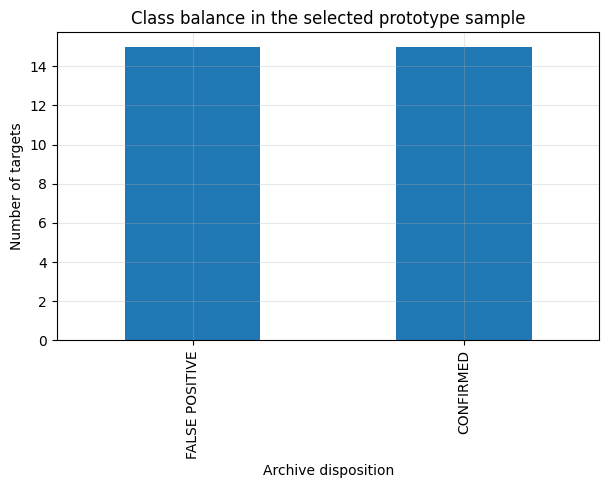

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
targets_df["koi_disposition"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Class balance in the selected prototype sample")
ax.set_xlabel("Archive disposition")
ax.set_ylabel("Number of targets")
plt.show()

## From raw archive entries to usable light curves

A row in the archive table is not yet a machine learning sample. I still need to go out to the Kepler archive, download the available light curves for that target, stitch multiple observing segments together, normalize them, remove large outliers, and flatten long-term trends.

This step deserves real attention because transit detection is not performed on raw flux in the most naive sense. The observed brightness of a star contains instrumental systematics, quarter-to-quarter offsets, stellar variability, and noise. A planetary transit is a comparatively small effect. If I do not remove long-timescale trends, the transit-search stage will waste effort explaining broad structure that is not the phenomenon I care about.

Flattening is therefore not cosmetic. It is a signal-isolation step. It tries to preserve short-duration, transit-like dips while suppressing slower baseline changes.

In [8]:
def choose_window_length(n_points: int) -> int:
    """Choose an odd Savitzky-Golay window length for Lightkurve.flatten()."""
    candidate = max(101, min(901, n_points // 20))
    if candidate % 2 == 0:
        candidate += 1
    return candidate


def download_and_prepare_lightcurve(kepid: int):
    """Download all long-cadence Kepler light curves for one target and prepare a flattened version."""
    search = lk.search_lightcurve(
        f"KIC {int(kepid)}",
        mission="Kepler",
        author="Kepler",
        cadence="long"
    )

    if len(search) == 0:
        raise ValueError("No Kepler light curve products were found.")

    collection = search.download_all(download_dir=str(LIGHTKURVE_CACHE_DIR))
    if collection is None or len(collection) == 0:
        raise ValueError("The search returned products, but download_all() produced no light curves.")

    stitched = collection.stitch(corrector_func=lambda lc: lc.remove_nans().normalize())
    stitched = stitched.remove_nans().remove_outliers(sigma=5)

    window_length = choose_window_length(len(stitched.time))
    flattened = stitched.flatten(window_length=window_length, polyorder=2, break_tolerance=5)
    flattened = flattened.remove_nans()

    if len(flattened.time) < 500:
        raise ValueError("The prepared light curve is too short after cleaning.")

    return stitched, flattened

## The transit search itself: why I use Box Least Squares

A transiting planet produces a repeating dip that is not sinusoidal. This detail is important. Many familiar time-series tools are excellent at recovering smooth periodic signals, but a transit is not a smooth wave. It is much closer to a repeating box-shaped decrease: out of transit the flux is roughly flat, then the flux drops for a short interval, then it returns.

That is the reasoning behind Box Least Squares. Instead of asking, “Which sinusoid best explains the data?”, BLS asks, “Which repeating box-like event best explains the data?” It evaluates many trial periods and durations, computes the quality of the best transit-like fit at each period, and returns a periodogram. The strongest peak in that periodogram is the strongest candidate periodic transit-like signal according to the chosen objective.

For this prototype I use the BLS output as a structured summary of each light curve. The best period, best duration, best depth, and the signal-to-noise of that solution are highly informative quantities. They are not the whole story, but they are an excellent starting point for a first classifier.

In [9]:
def robust_flux_arrays(lightcurve):
    time = np.asarray(lightcurve.time.value, dtype=float)
    flux = np.asarray(getattr(lightcurve.flux, "value", lightcurve.flux), dtype=float)

    if getattr(lightcurve, "flux_err", None) is not None:
        flux_err = np.asarray(getattr(lightcurve.flux_err, "value", lightcurve.flux_err), dtype=float)
        if not np.isfinite(flux_err).all() or np.nanmedian(flux_err) <= 0:
            flux_err = np.full_like(flux, np.nanstd(flux))
    else:
        flux_err = np.full_like(flux, np.nanstd(flux))

    mask = np.isfinite(time) & np.isfinite(flux) & np.isfinite(flux_err)
    time = time[mask]
    flux = flux[mask]
    flux_err = flux_err[mask]

    if len(time) < 500:
        raise ValueError("Too few finite observations remain after array filtering.")

    return time, flux, flux_err


def mad_normal(x):
    median = np.nanmedian(x)
    return 1.4826 * np.nanmedian(np.abs(x - median))


def build_period_duration_grids():
    periods = np.linspace(MIN_PERIOD_DAYS, MAX_PERIOD_DAYS, PERIOD_GRID_SIZE)
    durations = DURATION_GRID_HOURS / 24.0
    return periods, durations


def phase_fold_arrays(time, flux, period, t0):
    phase = ((time - t0 + 0.5 * period) % period) / period - 0.5
    order = np.argsort(phase)
    return phase[order], flux[order]


def compute_binned_phase_depth(phase, flux, n_bins=120):
    bins = np.linspace(-0.5, 0.5, n_bins + 1)
    digitized = np.digitize(phase, bins) - 1
    binned = np.array([
        np.nanmedian(flux[digitized == i]) if np.any(digitized == i) else np.nan
        for i in range(n_bins)
    ])
    baseline = np.nanmedian(binned)
    minimum = np.nanmin(binned)
    return baseline - minimum, np.nanstd(binned)


def compute_odd_even_depth_difference(time, flux, period, duration, t0):
    centers = []
    k_min = int(np.floor((time.min() - t0) / period)) - 1
    k_max = int(np.ceil((time.max() - t0) / period)) + 1

    for k in range(k_min, k_max + 1):
        centers.append(t0 + k * period)

    depths = []
    for center in centers:
        in_mask = np.abs(time - center) <= (duration / 2)
        local_mask = np.abs(time - center) <= (2 * duration)
        oot_mask = local_mask & (~in_mask)

        if in_mask.sum() >= 3 and oot_mask.sum() >= 5:
            baseline = np.nanmedian(flux[oot_mask])
            in_transit = np.nanmedian(flux[in_mask])
            depths.append(baseline - in_transit)

    if len(depths) < 4:
        return np.nan, len(depths)

    odd_depth = np.nanmedian(depths[::2])
    even_depth = np.nanmedian(depths[1::2])
    return np.abs(odd_depth - even_depth), len(depths)


def extract_transit_features(flattened_lc, catalog_period=None):
    time, flux, flux_err = robust_flux_arrays(flattened_lc)
    periods, durations = build_period_duration_grids()

    bls = BoxLeastSquares(time, flux, dy=flux_err)
    results = bls.power(periods, durations, objective="snr")

    best_idx = int(np.nanargmax(results.power))
    best_period = float(np.asarray(results.period)[best_idx])
    best_duration = float(np.asarray(results.duration)[best_idx])
    best_t0 = float(np.asarray(results.transit_time)[best_idx])
    best_depth = float(np.asarray(results.depth)[best_idx])
    best_power = float(np.asarray(results.power)[best_idx])
    best_depth_snr = float(np.asarray(results.depth_snr)[best_idx])

    transit_mask = bls.transit_mask(time, best_period, best_duration, best_t0)

    in_transit_flux = flux[transit_mask]
    out_of_transit_flux = flux[~transit_mask]

    if len(in_transit_flux) == 0 or len(out_of_transit_flux) == 0:
        raise ValueError("BLS transit mask produced an empty in-transit or out-of-transit region.")

    phase, folded_flux = phase_fold_arrays(time, flux, best_period, best_t0)
    phase_depth, phase_scatter = compute_binned_phase_depth(phase, folded_flux)
    odd_even_diff, n_measured_transits = compute_odd_even_depth_difference(
        time, flux, best_period, best_duration, best_t0
    )

    feature_row = {
        "n_points": len(time),
        "time_baseline_days": float(time.max() - time.min()),
        "flux_std": float(np.nanstd(flux)),
        "flux_mad": float(mad_normal(flux)),
        "bls_best_period": best_period,
        "bls_best_duration_hours": best_duration * 24.0,
        "bls_best_depth": best_depth,
        "bls_best_power": best_power,
        "bls_best_depth_snr": best_depth_snr,
        "in_transit_fraction": float(transit_mask.mean()),
        "transit_contrast": float(np.nanmedian(out_of_transit_flux) - np.nanmedian(in_transit_flux)),
        "phase_curve_depth": float(phase_depth),
        "phase_curve_scatter": float(phase_scatter),
        "odd_even_depth_difference": float(odd_even_diff) if np.isfinite(odd_even_diff) else np.nan,
        "n_measured_transits": int(n_measured_transits),
    }

    if catalog_period is not None and np.isfinite(catalog_period):
        feature_row["catalog_period_days"] = float(catalog_period)
        feature_row["period_recovery_abs_error_days"] = abs(best_period - float(catalog_period))
        feature_row["period_recovery_relative_error"] = abs(best_period - float(catalog_period)) / float(catalog_period)

    return feature_row, results

## Feature engineering philosophy

Feature engineering is where the light-curve analysis becomes machine learning input.

I am not feeding the entire flux sequence directly into the model. Instead, I am converting each target into a compact set of descriptive quantities. This is a strong decision for a first prototype because it forces me to make the physical reasoning explicit.

If the BLS search finds a meaningful candidate, I expect a useful signal summary to include at least the candidate period, candidate duration, candidate depth, and the significance of the fit. But those are not enough by themselves. I also want noise-sensitive quantities and morphology-sensitive quantities. For example, the general scatter of the flattened light curve matters because weak transits are harder to distinguish in noisy data. The phase-folded depth matters because it reflects how strongly a dip remains after all cycles are aligned on the candidate period. The odd-even depth difference matters because eclipsing binaries often show differences between alternating events, whereas planetary transits are expected to be more uniform.

This is the heart of the prototype. I am turning a time series into a structured description of what kind of periodic dip it contains.

In [10]:
def plot_target_diagnostics(kepid: int, title_prefix: str = ""):
    stitched, flattened = download_and_prepare_lightcurve(kepid)
    features, bls_results = extract_transit_features(flattened)

    time_raw = stitched.time.value
    flux_raw = np.asarray(getattr(stitched.flux, "value", stitched.flux), dtype=float)

    time = flattened.time.value
    flux = np.asarray(getattr(flattened.flux, "value", flattened.flux), dtype=float)

    best_period = features["bls_best_period"]
    best_duration = features["bls_best_duration_hours"] / 24.0

    bls = BoxLeastSquares(time, flux)
    periods = np.asarray(bls_results.period)
    powers = np.asarray(bls_results.power)
    best_idx = int(np.argmax(powers))
    best_t0 = float(np.asarray(bls_results.transit_time)[best_idx])

    phase, folded_flux = phase_fold_arrays(time, flux, best_period, best_t0)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    axes[0].plot(time_raw, flux_raw, ".", ms=1, alpha=0.6)
    axes[0].set_title(f"{title_prefix}Raw / stitched light curve")
    axes[0].set_xlabel("Time [BKJD]")
    axes[0].set_ylabel("Normalized flux")

    axes[1].plot(periods, powers, lw=1.5)
    axes[1].axvline(best_period, linestyle="--")
    axes[1].set_title("BLS periodogram")
    axes[1].set_xlabel("Period [days]")
    axes[1].set_ylabel("BLS power")

    axes[2].plot(phase, folded_flux, ".", ms=2, alpha=0.5)
    axes[2].set_xlim(-0.1, 0.1)
    axes[2].set_title("Phase-folded signal near transit")
    axes[2].set_xlabel("Orbital phase")
    axes[2].set_ylabel("Flattened flux")

    plt.tight_layout()
    plt.show()

    return features

In [11]:
def build_feature_table(targets: pd.DataFrame):
    records = []
    failures = []

    for row in targets.itertuples(index=False):
        try:
            _, flattened = download_and_prepare_lightcurve(row.kepid)
            features, _ = extract_transit_features(flattened, catalog_period=row.koi_period)

            record = {
                "kepid": int(row.kepid),
                "kepoi_name": row.kepoi_name,
                "koi_disposition": row.koi_disposition,
                "label": int(row.label),
                "catalog_depth_ppm": row.koi_depth,
                "catalog_duration_hours": row.koi_duration,
            }
            record.update(features)
            records.append(record)
        except Exception as exc:
            failures.append({
                "kepid": int(row.kepid),
                "kepoi_name": row.kepoi_name,
                "koi_disposition": row.koi_disposition,
                "error": str(exc)
            })

    features_df = pd.DataFrame(records)
    failures_df = pd.DataFrame(failures)
    return features_df, failures_df

In [12]:
if REBUILD_FEATURES or not FEATURE_CACHE_PATH.exists():
    features_df, failures_df = build_feature_table(targets_df)
    features_df.to_csv(FEATURE_CACHE_PATH, index=False)
    failures_df.to_csv(FAILURE_CACHE_PATH, index=False)
else:
    features_df = pd.read_csv(FEATURE_CACHE_PATH)
    failures_df = pd.read_csv(FAILURE_CACHE_PATH) if FAILURE_CACHE_PATH.exists() else pd.DataFrame()

print(f"Successful feature rows: {len(features_df)}")
print(f"Failed targets: {len(failures_df)}")
features_df.head()

Successful feature rows: 30
Failed targets: 0


,kepid,kepoi_name,koi_disposition,label,catalog_depth_ppm,catalog_duration_hours,n_points,time_baseline_days,flux_std,flux_mad,bls_best_period,bls_best_duration_hours,bls_best_depth,bls_best_power,bls_best_depth_snr,in_transit_fraction,transit_contrast,phase_curve_depth,phase_curve_scatter,odd_even_depth_difference,n_measured_transits,catalog_period_days,period_recovery_abs_error_days,period_recovery_relative_error
0,8262210,K01073.01,FALSE POSITIVE,0,104.1,2.3940,63100,1421.235719,0.000296,0.000288,1.612745,7.0,0.000041,15.150245,15.150245,0.180571,0.000037,0.000062,0.000025,0.000011,819,1.613001,0.000256,0.000159
1,9790965,K07231.01,FALSE POSITIVE,0,26189.8,3.8281,52204,1470.462398,0.007725,0.006769,4.932773,3.0,0.012489,3309.344040,3309.344040,0.025956,0.011121,0.015559,0.005979,0.000309,224,0.822068,4.110705,5.000447
2,12935144,K02847.01,FALSE POSITIVE,0,282.6,1.7650,64735,1459.489403,0.000824,0.000784,14.869748,11.0,0.000154,9.904530,9.904530,0.031019,0.000141,0.000153,0.000068,0.000073,93,1.099291,13.770457,12.526669
3,7697568,K01829.02,FALSE POSITIVE,0,255.1,2.0890,63170,1421.235761,0.002777,0.002444,18.744398,12.0,0.002127,159.505572,159.505572,0.026864,0.001878,0.001959,0.000949,0.000122,70,10.348211,8.396187,0.811366
4,3346154,K02723.01,CONFIRMED,1,403.0,0.8720,64733,1459.488848,0.000342,0.000320,13.668067,2.0,0.000152,10.141733,10.141733,0.006117,0.000148,0.000084,0.000022,0.000002,98,1.952711,11.715356,5.999534


## Interpreting the feature table before modeling

At this point the notebook has completed its most important transformation. It started with archive labels and raw light curves. It now has one row per successfully processed target, where each row contains a distilled numerical summary of the strongest transit-like signal found by BLS.

This is the moment where the notebook stops being only an astronomy workflow and becomes a machine learning dataset.

I still need to inspect it before training anything. A good prototype does not rush into modeling. It first checks whether feature extraction succeeded often enough, whether the classes remain reasonably balanced after failures, whether the features look finite, and whether the recovered signal summaries look plausible. If the feature table is corrupted, the model can still produce numbers, but those numbers would have no credibility.

In [13]:
features_df["koi_disposition"].value_counts()

koi_disposition
FALSE POSITIVE    15
CONFIRMED         15
Name: count, dtype: int64

In [14]:
features_df.isna().mean().sort_values(ascending=False)

kepid                             0.0
kepoi_name                        0.0
koi_disposition                   0.0
label                             0.0
catalog_depth_ppm                 0.0
catalog_duration_hours            0.0
n_points                          0.0
time_baseline_days                0.0
flux_std                          0.0
flux_mad                          0.0
bls_best_period                   0.0
bls_best_duration_hours           0.0
bls_best_depth                    0.0
bls_best_power                    0.0
bls_best_depth_snr                0.0
in_transit_fraction               0.0
transit_contrast                  0.0
phase_curve_depth                 0.0
phase_curve_scatter               0.0
odd_even_depth_difference         0.0
n_measured_transits               0.0
catalog_period_days               0.0
period_recovery_abs_error_days    0.0
period_recovery_relative_error    0.0
dtype: float64

In [15]:
if len(failures_df) > 0:
    failures_df.head(10)
else:
    print("No failed targets were recorded in this run.")

No failed targets were recorded in this run.


In [16]:
numeric_preview_cols = [
    "flux_std",
    "flux_mad",
    "bls_best_period",
    "bls_best_duration_hours",
    "bls_best_depth",
    "bls_best_power",
    "bls_best_depth_snr",
    "phase_curve_depth",
    "odd_even_depth_difference",
    "period_recovery_relative_error",
]
features_df[numeric_preview_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
flux_std,30.0,0.001641,0.002374,0.000126,0.000319,0.000520,0.001312,0.007725
flux_mad,30.0,0.001455,0.002092,0.000120,0.000303,0.000467,0.001216,0.006865
bls_best_period,30.0,9.797782,4.717860,1.612745,5.924545,10.494398,13.371499,18.744398
bls_best_duration_hours,30.0,6.700000,4.284294,1.000000,2.250000,6.000000,12.000000,12.000000
bls_best_depth,30.0,0.001860,0.003842,0.000041,0.000154,0.000309,0.001081,0.017179
bls_best_power,30.0,383.512374,884.752845,8.878332,19.631349,39.765583,155.177083,3309.344040
bls_best_depth_snr,30.0,383.512374,884.752845,8.878332,19.631349,39.765583,155.177083,3309.344040
phase_curve_depth,30.0,0.002456,0.006690,0.000043,0.000134,0.000303,0.001012,0.034181
odd_even_depth_difference,30.0,0.000160,0.000322,0.000002,0.000011,0.000038,0.000121,0.001442
period_recovery_relative_error,30.0,3.570977,4.164017,0.000003,0.503321,1.387993,5.724047,12.999830


## A few diagnostic plots before the model sees the data

I want a visual sense of how separable the classes might be before training begins. This does not replace formal evaluation, but it helps me see whether the engineered features contain useful structure.

If a prototype is working at all, I would usually expect at least some weak class separation in variables such as BLS depth, BLS depth SNR, phase-folded depth, and odd-even depth difference. A perfect separation would be suspicious in such a small first version. Partial structure is more realistic.

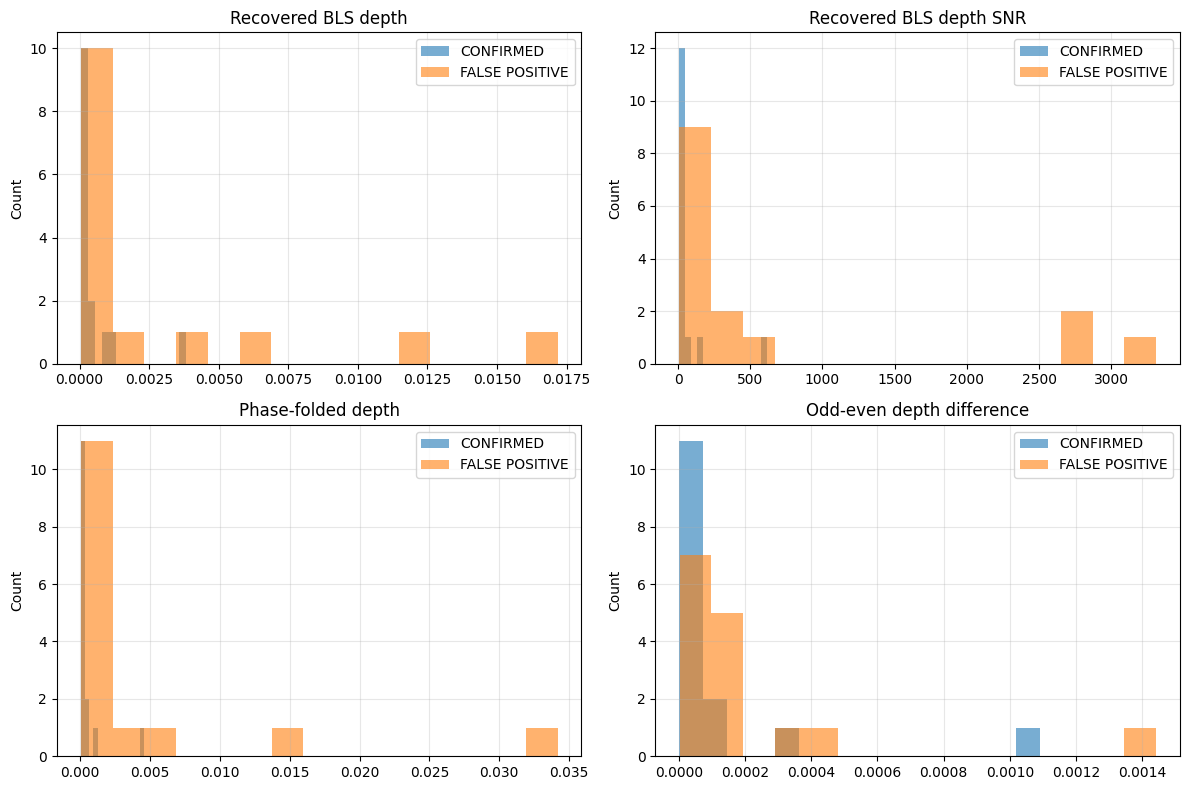

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for disposition, group in features_df.groupby("koi_disposition"):
    axes[0, 0].hist(group["bls_best_depth"], bins=15, alpha=0.6, label=disposition)
    axes[0, 1].hist(group["bls_best_depth_snr"], bins=15, alpha=0.6, label=disposition)
    axes[1, 0].hist(group["phase_curve_depth"], bins=15, alpha=0.6, label=disposition)
    axes[1, 1].hist(group["odd_even_depth_difference"].dropna(), bins=15, alpha=0.6, label=disposition)

axes[0, 0].set_title("Recovered BLS depth")
axes[0, 1].set_title("Recovered BLS depth SNR")
axes[1, 0].set_title("Phase-folded depth")
axes[1, 1].set_title("Odd-even depth difference")

for ax in axes.ravel():
    ax.legend()
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## Sample light-curve diagnostics

A feature table is useful, but I also want to look at the actual astrophysical objects behind some rows. That keeps the notebook grounded in the original scientific signal.

I am plotting one confirmed target and one false-positive target below. For each one I show the stitched light curve, the BLS periodogram, and the phase-folded signal around the recovered transit. This makes the link between the raw observations and the engineered features visible.

If the pipeline is behaving sensibly, the BLS peak should correspond to a visible folded dip, even when the object is later classified as a false positive by the archive.

In [18]:
example_confirmed = int(features_df.loc[features_df["label"] == 1, "kepid"].iloc[0])
example_false_positive = int(features_df.loc[features_df["label"] == 0, "kepid"].iloc[0])

print(f"Confirmed example KIC: {example_confirmed}")
print(f"False-positive example KIC: {example_false_positive}")

Confirmed example KIC: 3346154
False-positive example KIC: 8262210


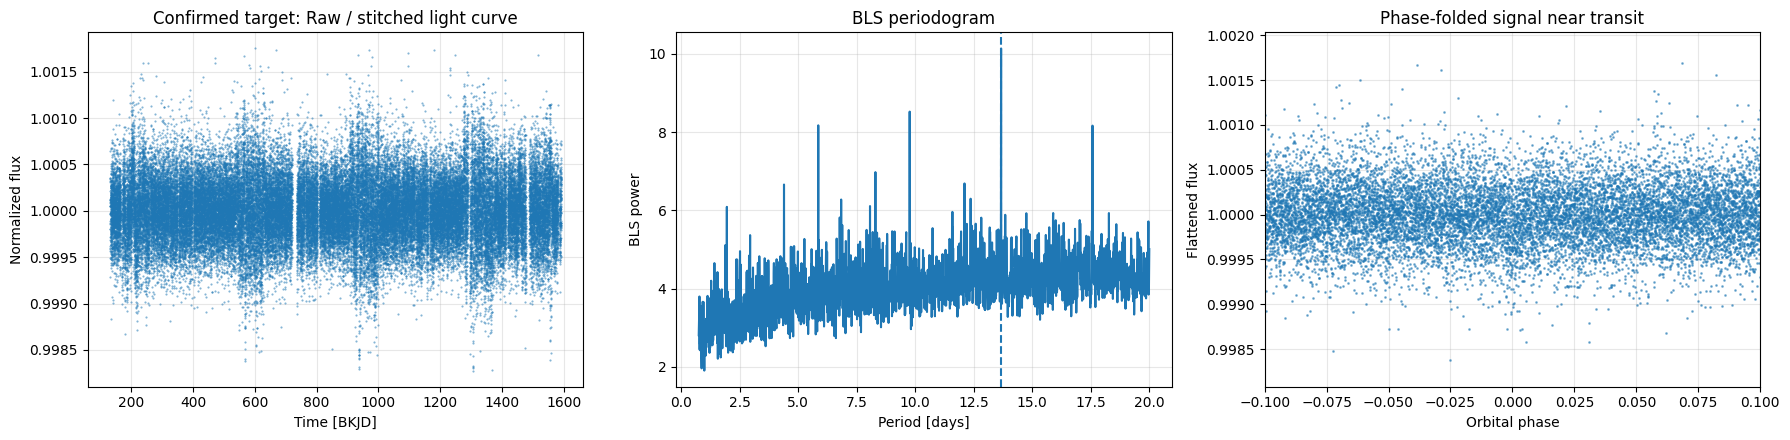

{'n_points': 64733,
 'time_baseline_days': 1459.4888484571202,
 'flux_std': 0.0003420517176668758,
 'flux_mad': 0.00032017125832588223,
 'bls_best_period': 13.668067226890757,
 'bls_best_duration_hours': 2.0,
 'bls_best_depth': 0.00015184145180034534,
 'bls_best_power': 10.14173311596558,
 'bls_best_depth_snr': 10.14173311596558,
 'in_transit_fraction': 0.006117436238085675,
 'transit_contrast': 0.00014833096556809977,
 'phase_curve_depth': 8.392340738438975e-05,
 'phase_curve_scatter': 2.2342762011575713e-05,
 'odd_even_depth_difference': 1.5737909627722146e-06,
 'n_measured_transits': 98}

In [19]:
confirmed_example_features = plot_target_diagnostics(example_confirmed, title_prefix="Confirmed target: ")
confirmed_example_features

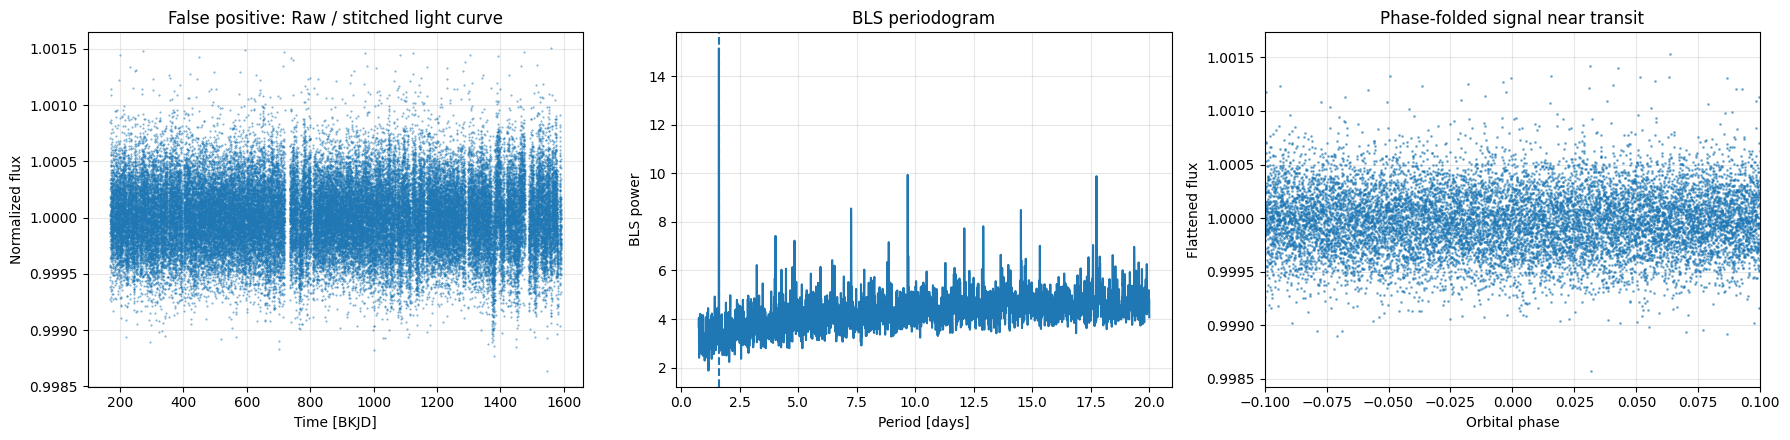

{'n_points': 63100,
 'time_baseline_days': 1421.2357191222764,
 'flux_std': 0.00029597076919727315,
 'flux_mad': 0.00028764890974745195,
 'bls_best_period': 1.6127450980392157,
 'bls_best_duration_hours': 7.0,
 'bls_best_depth': 4.0706343123797034e-05,
 'bls_best_power': 15.150244775109472,
 'bls_best_depth_snr': 15.150244775109472,
 'in_transit_fraction': 0.18057052297939777,
 'transit_contrast': 3.7044047514256384e-05,
 'phase_curve_depth': 6.24756122254988e-05,
 'phase_curve_scatter': 2.469290909776747e-05,
 'odd_even_depth_difference': 1.1486307584906985e-05,
 'n_measured_transits': 819}

In [20]:
false_positive_example_features = plot_target_diagnostics(example_false_positive, title_prefix="False positive: ")
false_positive_example_features

## Choosing the model family for a first prototype

A first notebook prototype benefits from models that are fast, interpretable, and stable on small tabular datasets.

For that reason I am starting with two classical models. The first is logistic regression. This is a strong baseline because it is simple, probabilistic, and easy to explain. If logistic regression already performs above chance, that tells me the feature engineering has captured useful signal. The second is a random forest. This gives me a non-linear model that can capture interactions between features and also provides a straightforward feature-importance estimate.

I am not treating the model as the center of the project. The main scientific work in this prototype is upstream of the model: archive selection, light-curve preparation, BLS recovery, and feature engineering. The classifier sits on top of that structure. It is important, but it is not magic.

In [21]:
model_features = [
    "n_points",
    "time_baseline_days",
    "flux_std",
    "flux_mad",
    "bls_best_period",
    "bls_best_duration_hours",
    "bls_best_depth",
    "bls_best_power",
    "bls_best_depth_snr",
    "in_transit_fraction",
    "transit_contrast",
    "phase_curve_depth",
    "phase_curve_scatter",
    "odd_even_depth_difference",
    "n_measured_transits",
]

X = features_df[model_features].copy()
y = features_df["label"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

logreg_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE))
])

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

models = {
    "Logistic Regression": logreg_pipeline,
    "Random Forest": rf_pipeline,
}

## Why I evaluate with cross-validation first

A small prototype dataset is vulnerable to lucky and unlucky train-test splits. If I report one single holdout score and stop there, the result may reflect the split as much as the model quality.

Cross-validation reduces that risk by rotating the train-validation partitions and showing how the model behaves across multiple folds. This is especially important in a first notebook where the sample size is modest. The point is not to claim a final leaderboard. The point is to estimate whether the pipeline has learned something repeatable.

After cross-validation I still keep a final holdout evaluation because that is how I want to present the result: first I show that the model behaves reasonably across folds, then I fit on the training set and inspect the final test predictions.

In [22]:
cv_splits = min(5, y.value_counts().min())
cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_rows = []

for model_name, pipeline in models.items():
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=None
    )

    row = {"model": model_name}
    for metric_name in scoring:
        metric_values = scores[f"test_{metric_name}"]
        row[f"{metric_name}_mean"] = np.mean(metric_values)
        row[f"{metric_name}_std"] = np.std(metric_values)
    cv_rows.append(row)

cv_results_df = pd.DataFrame(cv_rows).sort_values("roc_auc_mean", ascending=False)
cv_results_df.to_csv(CV_RESULTS_PATH, index=False)
cv_results_df

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Logistic Regression,0.666667,0.105409,0.673333,0.171788,0.733333,0.249444,0.673333,0.143217,0.644444,0.177778
1,Random Forest,0.633333,0.124722,0.640000,0.185472,0.733333,0.249444,0.654286,0.149051,0.600000,0.150718


In [23]:
best_model_name = cv_results_df.iloc[0]["model"]
best_pipeline = models[best_model_name]

print(f"Selected best prototype model: {best_model_name}")

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["False Positive", "Confirmed"]))
print(f"Holdout ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

Selected best prototype model: Logistic Regression
                precision    recall  f1-score   support

False Positive       0.50      0.50      0.50         4
     Confirmed       0.50      0.50      0.50         4

      accuracy                           0.50         8
     macro avg       0.50      0.50      0.50         8
  weighted avg       0.50      0.50      0.50         8

Holdout ROC-AUC: 0.438


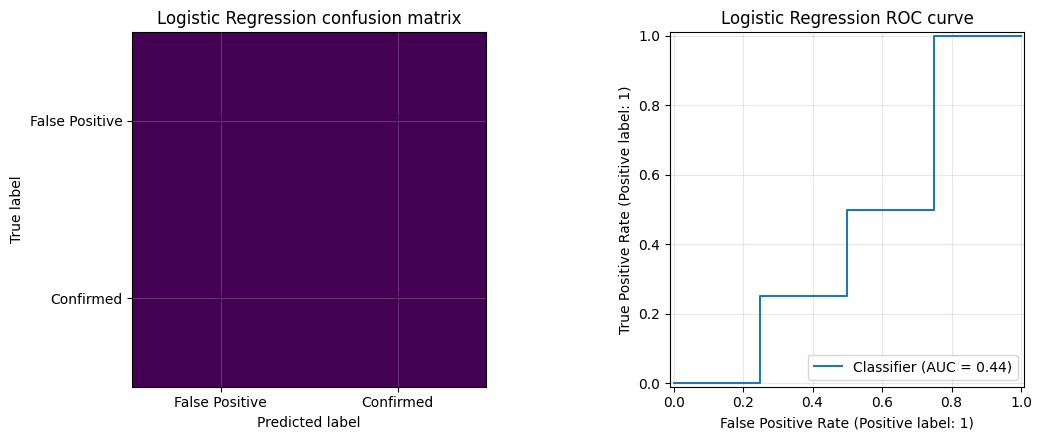

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["False Positive", "Confirmed"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f"{best_model_name} confusion matrix")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title(f"{best_model_name} ROC curve")

plt.tight_layout()
plt.show()

## Interpreting the evaluation carefully

The metrics above tell me whether the prototype has learned a non-trivial distinction, but they do not yet justify grand claims.

A strong first prototype would show that the model can separate the two archive dispositions above chance and that the behavior is at least moderately stable across cross-validation folds. That would already be a meaningful result because the model is learning from features derived from real Kepler light curves rather than from canned demo values.

At the same time, I need to be strict about the limitations. The dataset is small. The labels come from archive dispositions rather than from a custom vetting campaign designed for this exact notebook. The BLS configuration is intentionally compact so that the prototype remains fast enough to demonstrate. The purpose of the result is therefore to validate the workflow, not to declare a final scientific classifier.

In [25]:
if best_model_name == "Random Forest":
    trained_rf = best_pipeline.named_steps["model"]
    importances = pd.DataFrame({
        "feature": model_features,
        "importance": trained_rf.feature_importances_
    }).sort_values("importance", ascending=False)

    importances.to_csv(FEATURE_IMPORTANCE_PATH, index=False)
    importances
else:
    trained_logreg = best_pipeline.named_steps["model"]
    coefficients = pd.DataFrame({
        "feature": model_features,
        "coefficient": trained_logreg.coef_[0]
    }).sort_values("coefficient", key=np.abs, ascending=False)
    importances = coefficients.rename(columns={"coefficient": "importance"})
    importances

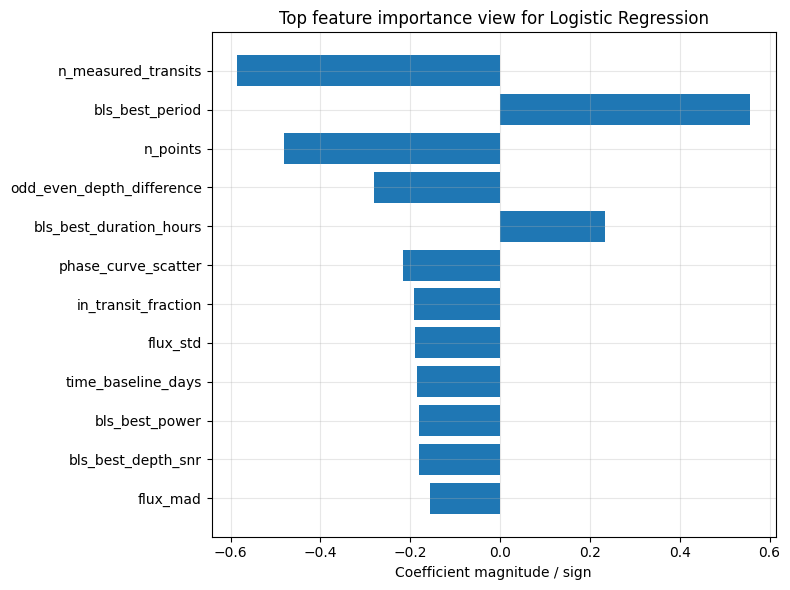

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
top_plot = importances.head(12).iloc[::-1]
ax.barh(top_plot["feature"], top_plot["importance"])
ax.set_title(f"Top feature importance view for {best_model_name}")
ax.set_xlabel("Importance" if best_model_name == "Random Forest" else "Coefficient magnitude / sign")
plt.tight_layout()
plt.show()

## What the most important features are telling me

Feature importance is useful because it lets me inspect which parts of the transit-search summary the model relies on most strongly. If I see variables such as BLS depth, BLS depth SNR, phase-folded depth, or odd-even depth difference near the top, that is scientifically reassuring. Those are exactly the kinds of quantities I would expect to matter in a transit-vetting context.

This is one reason I preferred a feature-based first prototype. I can connect the model's behavior back to interpretable properties of the signal. I do not need to treat the classifier as a black box. Even when the performance is modest, I can still explain what the model is looking at.

## Optional notebook-only interactive inspection

If I want an additional demonstration moment inside Jupyter Lab, Lightkurve also supports an interactive BLS viewer. I am leaving the cell below commented out because it is optional and depends on the notebook frontend handling Bokeh widgets cleanly. Still, it is a nice presentation feature because it makes the prototype feel alive rather than static.

In [27]:
# Optional interactive exploration in Jupyter Lab / Notebook:
# stitched, flattened = download_and_prepare_lightcurve(example_confirmed)
# flattened.interact_bls()

## Final conclusion for this prototype stage

This notebook already demonstrates the backbone of the project.

I start from a professional archive label source. I fetch real Kepler targets. I retrieve and prepare the light curves with Lightkurve. I search for transit-like signals with Box Least Squares. I summarize those signals using engineered features rooted in the structure of planetary transits and common false-positive behavior. I then train and evaluate a first tabular classifier on those features.

That makes this notebook a legitimate first prototype of an exoplanet transit detection workflow.

It is not the final version. A stronger next version would include a larger sample, more careful negative-class design, richer vetting features, possibly multiple candidate peaks per light curve, better handling of quarter-level systematics, and eventually a comparison against sequence-based models that operate more directly on the folded or detrended light curves. But those are next-stage improvements. For a first version, the notebook already proves that the project can move from astrophysical data to a machine-learning decision pipeline in one coherent, reproducible workflow.

## Suggested next steps I would present after the prototype

The natural continuation from here is not to throw everything away and start over. The natural continuation is to strengthen each stage.

First, I would expand the target set so that the model sees more variability regimes and a broader range of transit morphologies. Second, I would improve candidate vetting by adding more physically meaningful features, especially features that separate planetary transits from eclipsing binaries and instrumental artifacts. Third, I would compare the current engineered-feature classifier against a more direct representation, such as binned phase-folded flux windows. Fourth, I would add experiment tracking and a cleaner error-analysis section, because the most valuable prototype mistakes are the ones I can explain.

That is how I would defend the project trajectory. The prototype is already real. The next phase is refinement, scale, and stronger scientific discrimination.